In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

In [25]:
data=np.random.exponential(scale=2,size=1000)
df=pd.DataFrame({"Salary":data})


In [26]:
df.head()

,Salary
0,2.911542
1,0.334185
2,1.353964
3,0.604214
4,0.857308


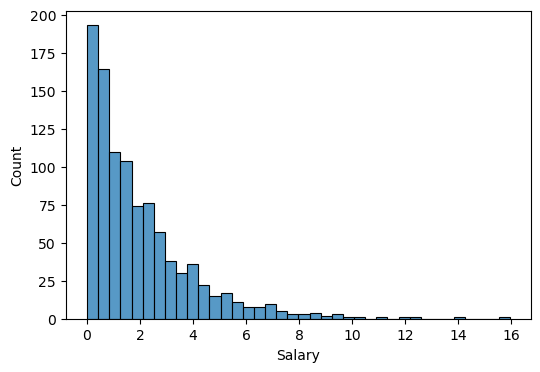

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df.Salary)
plt.show()

In [28]:
df.Salary.skew()

np.float64(2.055069941669638)

In [29]:
df["updated_salary"],lambda_val=boxcox(df.Salary)


In [30]:
df.head()

,Salary,updated_salary
0,2.911542,1.233042
1,0.334185,-0.952908
2,1.353964,0.315374
3,0.604214,-0.472032
4,0.857308,-0.150899


In [31]:
lambda_val

np.float64(0.2616334990495803)

In [32]:
df.updated_salary.skew()

np.float64(-0.034847105708030485)

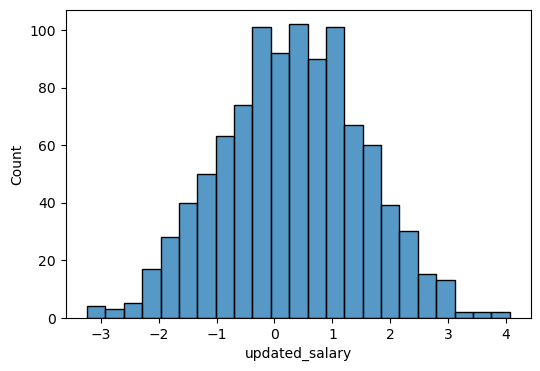

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(df.updated_salary)
plt.show()

In [34]:
##left skewed distribution


In [35]:
data=np.random.exponential(scale=2,size=1000)
data=10-data
df=pd.DataFrame({"Salary2":data})

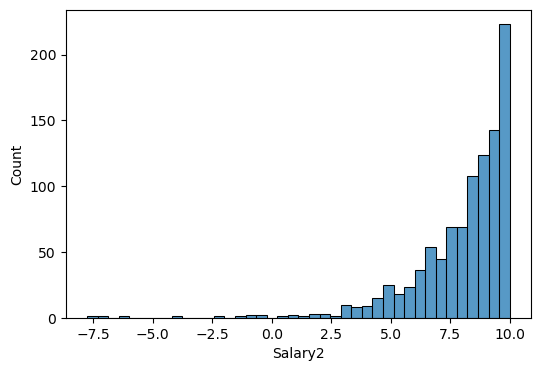

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(df.Salary2)
plt.show()

In [41]:
df["reflex_salary"]=(df.Salary2.max()-df.Salary2)+1

In [42]:
df.head()

,Salary2,reflex_salary,Transformed_salary
0,9.041716,1.949739,0.948432
1,7.135362,3.856093,2.049455
2,3.436092,7.555363,2.880283
3,7.561283,3.430172,1.887962
4,6.127907,4.863548,2.351586


In [43]:
df.Salary2.skew()

np.float64(-2.518139110723944)

In [46]:
max(df.reflex_salary), min(df.reflex_salary)

(18.7423752973209, 1.0)

In [47]:
df["Transformed_salary"]=np.log(df.reflex_salary)

In [48]:
df.Transformed_salary.skew()

np.float64(0.447824272578193)

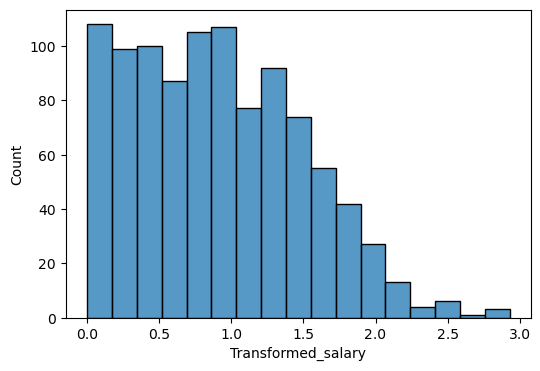

In [52]:
plt.figure(figsize=(6,4))
sns.histplot(df.Transformed_salary)
plt.show()

In [59]:
z=pd.read_csv(r"C:\Users\ruthu\Downloads\test2.csv")


In [60]:
z

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,NaN,IT,62000.0
4,4,Eve,29.0,HR,NaN
5,5,Alice,25.0,HR,50000.0


In [63]:
z.shape

(6, 5)

In [68]:
z.Age=z.Age.fillna(value=z.Age.mean())
z.Salary=z.Salary.fillna(value=z.Salary.mean())


In [69]:
z

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,28.8,IT,62000.0
4,4,Eve,29.0,HR,58400.0
5,5,Alice,25.0,HR,50000.0


In [70]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [71]:
encoder = LabelEncoder()

In [72]:
z["Transformed_name"] = encoder.fit_transform(z.Name)

In [73]:
z.head()

,Unnamed: 0,Name,Age,Department,Salary,Transformed_name
0,0,Alice,25.0,HR,50000.0,0
1,1,Bob,30.0,IT,60000.0,1
2,2,Charlie,35.0,Finance,70000.0,2
3,3,David,28.8,IT,62000.0,3
4,4,Eve,29.0,HR,58400.0,4


In [75]:
z[["Department"]].shape

(6, 1)

In [76]:
encoder2 = OneHotEncoder(sparse_output=False)

In [79]:
encoded=encoder2.fit_transform(z[["Department"]])

In [80]:
encoder2.get_feature_names_out()

array(['Department_Finance', 'Department_HR', 'Department_IT'],
      dtype=object)

In [81]:
encoded

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [83]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [84]:
scaler = StandardScaler()

In [85]:
z["scaled_salary"] = scaler.fit_transform(z[["Salary"]])

In [86]:
z.head()

,Unnamed: 0,Name,Age,Department,Salary,Transformed_name,scaled_salary
0,0,Alice,25.0,HR,50000.0,0,-1.205755
1,1,Bob,30.0,IT,60000.0,1,0.229668
2,2,Charlie,35.0,Finance,70000.0,2,1.665091
3,3,David,28.8,IT,62000.0,3,0.516752
4,4,Eve,29.0,HR,58400.0,4,0.000000


In [90]:
Min_Max=MinMaxScaler()

In [91]:
z["Min_Max"]=Min_Max.fit_transform(z[["Salary"]])
z

,Unnamed: 0,Name,Age,Department,Salary,Transformed_name,scaled_salary,Min_Max
0,0,Alice,25.0,HR,50000.0,0,-1.205755,0.00
1,1,Bob,30.0,IT,60000.0,1,0.229668,0.50
2,2,Charlie,35.0,Finance,70000.0,2,1.665091,1.00
3,3,David,28.8,IT,62000.0,3,0.516752,0.60
4,4,Eve,29.0,HR,58400.0,4,0.000000,0.42
5,5,Alice,25.0,HR,50000.0,0,-1.205755,0.00


In [92]:
#By using matplotlib and seaborn we should plot all these

#line chart - Time series
#bar chart - data distribution of categories
#histogram - single column distribution
#scatter plot - relationship btwn 2 variables
#pie chart - distribution of categories
#pair plot - heatmap [-1, 0, 1]
#dot plot - box plot

In [95]:
p=pd.read_csv(r"C:\Users\ruthu\Downloads\data_visualization.csv")
p

,Unnamed: 0,Student_ID,Name,Gender,Department,Age,Math_Score,Science_Score,Attendance_Percentage,Study_Hours_per_Week
0,0,1,Aarav,Male,CS,21,78,75,85,10
1,1,2,Diya,Female,IT,22,85,88,90,12
2,2,3,Rohan,Male,CS,20,90,85,95,15
3,3,4,Sneha,Female,ECE,21,67,70,80,8
4,4,5,Arjun,Male,IT,23,88,90,92,14
5,5,6,Meera,Female,ECE,22,76,79,88,9
6,6,7,Kiran,Male,CS,21,92,94,96,16
7,7,8,Ananya,Female,IT,20,81,83,89,11
8,8,9,Rahul,Male,ECE,22,74,72,75,7
9,9,10,Isha,Female,CS,23,89,91,93,15


In [96]:
p.head()

,Unnamed: 0,Student_ID,Name,Gender,Department,Age,Math_Score,Science_Score,Attendance_Percentage,Study_Hours_per_Week
0,0,1,Aarav,Male,CS,21,78,75,85,10
1,1,2,Diya,Female,IT,22,85,88,90,12
2,2,3,Rohan,Male,CS,20,90,85,95,15
3,3,4,Sneha,Female,ECE,21,67,70,80,8
4,4,5,Arjun,Male,IT,23,88,90,92,14


<Figure size 640x480 with 0 Axes>

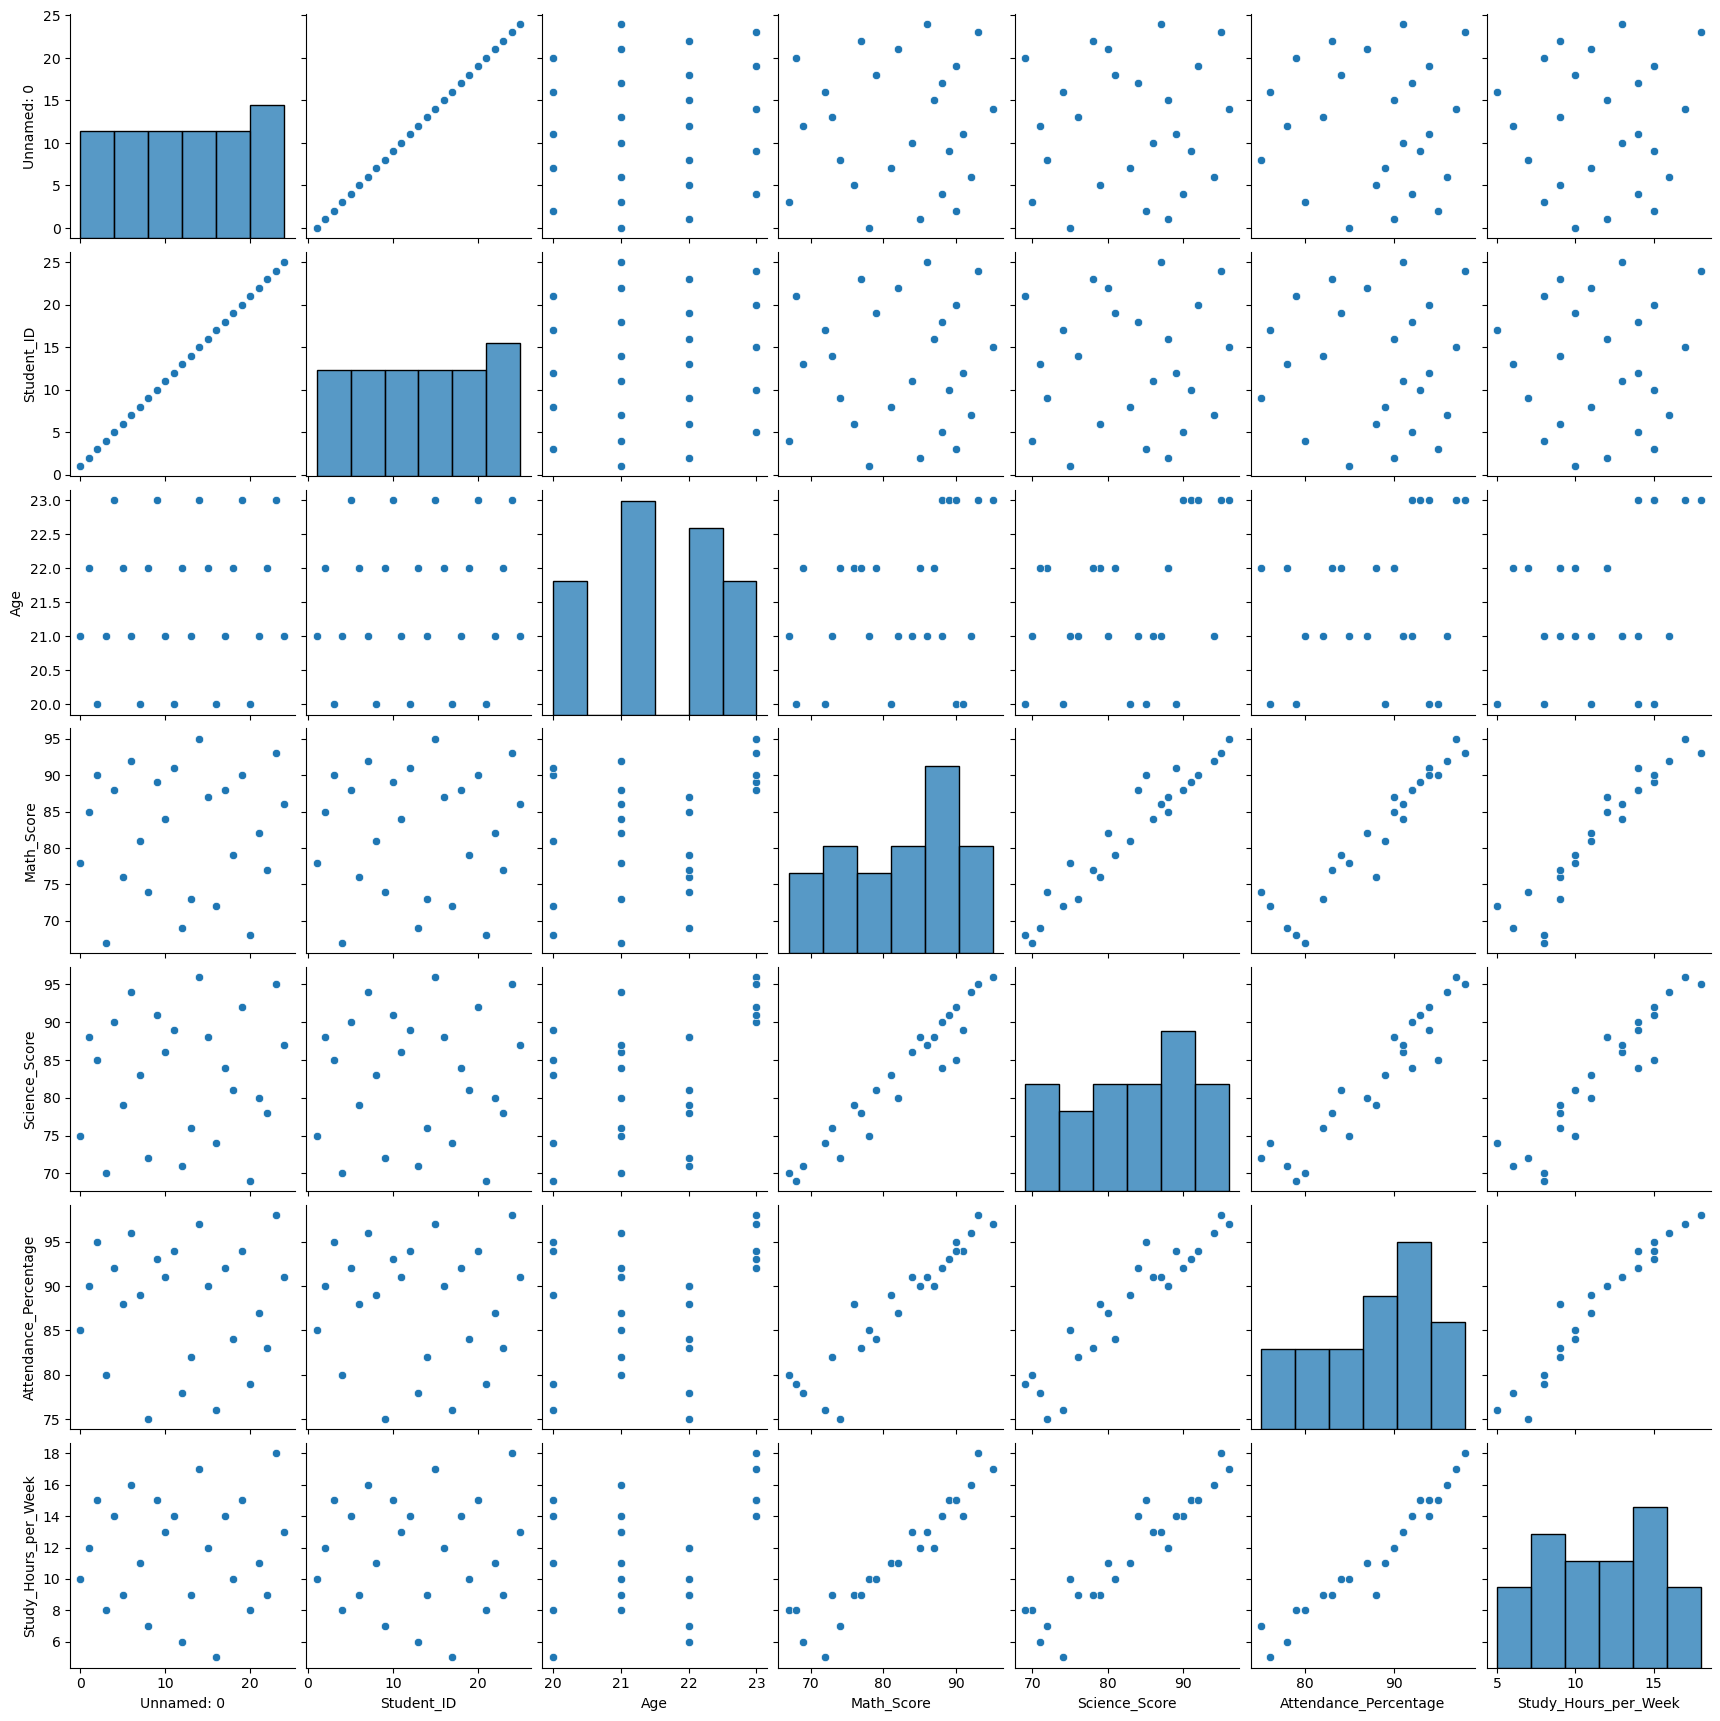

In [99]:
plt.figure()
sns.pairplot(p)

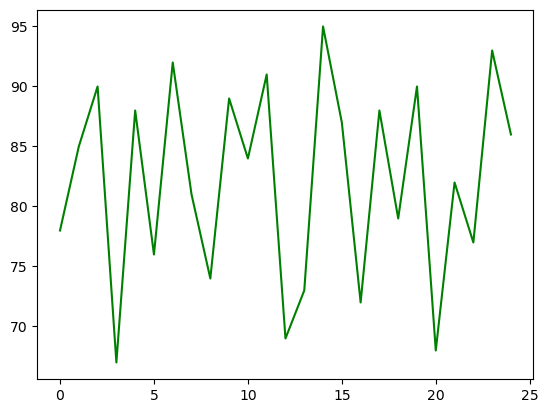

In [101]:
plt.plot(p.Math_Score,color="green")

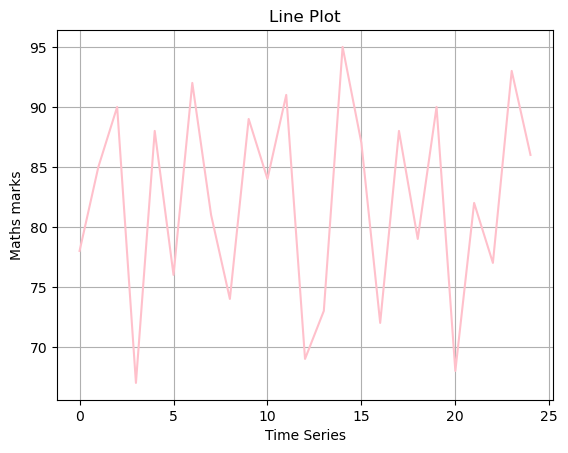

In [110]:
plt.plot(p.Math_Score,color="pink")
plt.grid()
plt.title("Line Plot")
plt.xlabel("Time Series")
plt.ylabel("Maths marks")
plt.show()

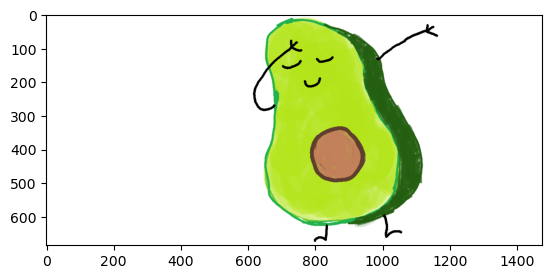

In [104]:
imp=plt.imread(r"C:\Users\ruthu\OneDrive\Pictures\Screenshots\R.png")
plt.imshow(imp)

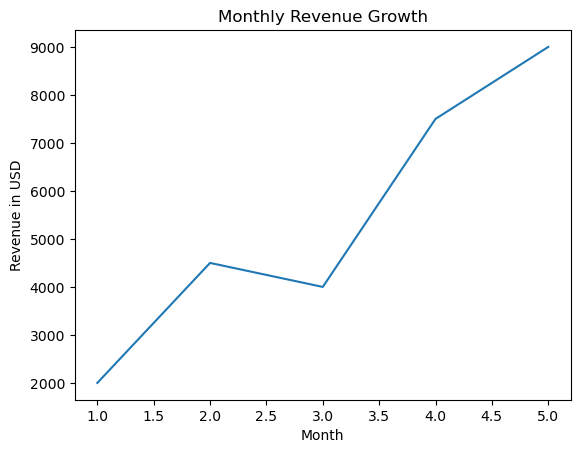

In [105]:
import matplotlib.pyplot as plt

months = [1, 2, 3, 4, 5]
revenue = [2000, 4500, 4000, 7500, 9000]

plt.plot(months, revenue)

plt.title("Monthly Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue in USD")
plt.show()


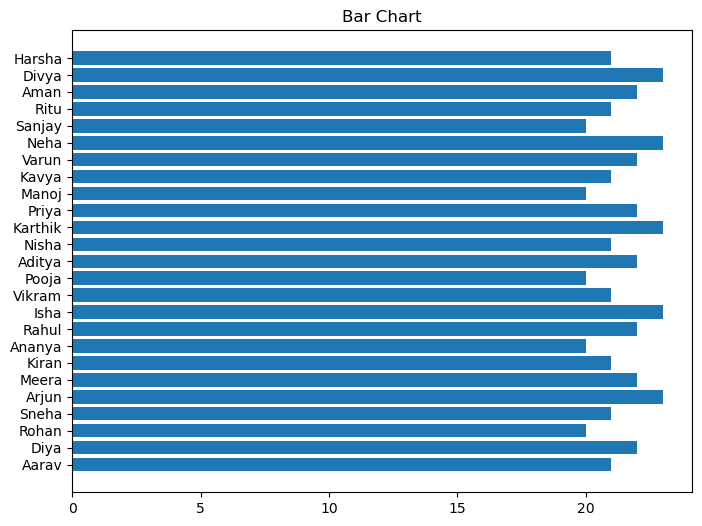

In [106]:
plt.figure(figsize=(8,6))
plt.barh(p["Name"], p["Age"])

plt.title("Bar Chart")
plt.show()

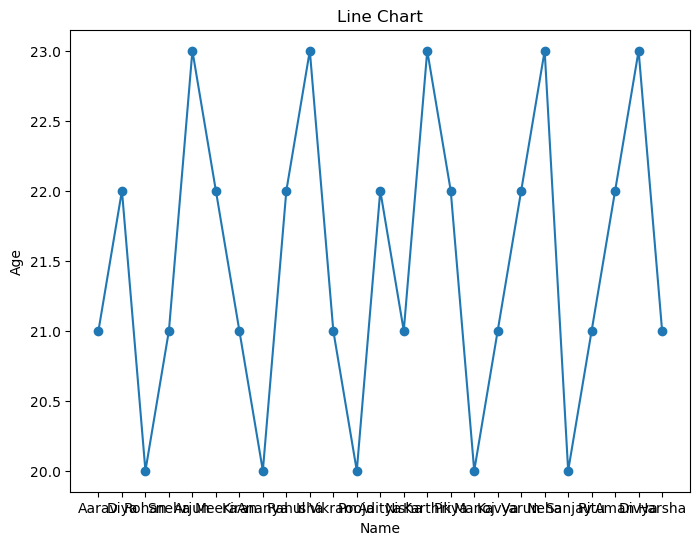

In [107]:
plt.figure(figsize=(8,6))

plt.plot(p["Name"], p["Age"], marker='o')

plt.title("Line Chart")
plt.xlabel("Name")
plt.ylabel("Age")

plt.show()


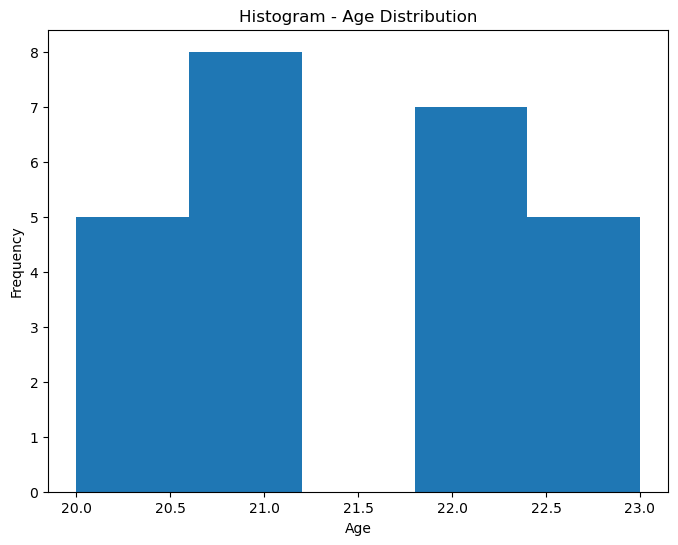

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(p["Age"], bins=5)

plt.title("Histogram - Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()


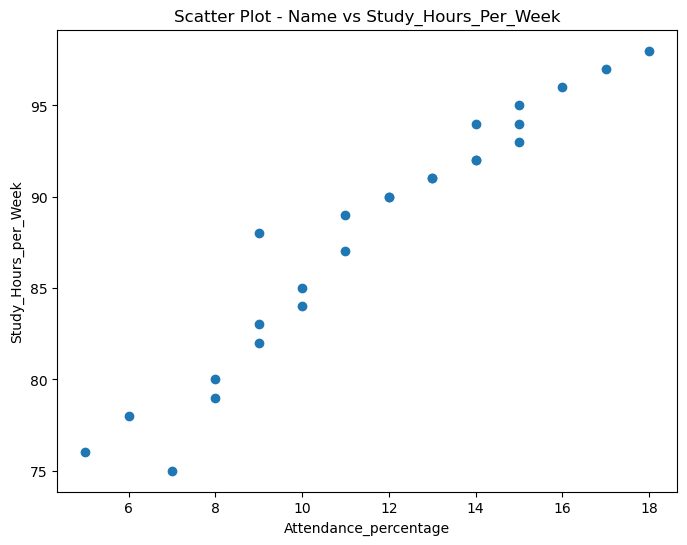

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(p["Study_Hours_per_Week"], p["Attendance_Percentage"])

plt.title("Scatter Plot - Name vs Study_Hours_Per_Week")
plt.xlabel("Attendance_percentage")
plt.ylabel("Study_Hours_per_Week")

plt.show()


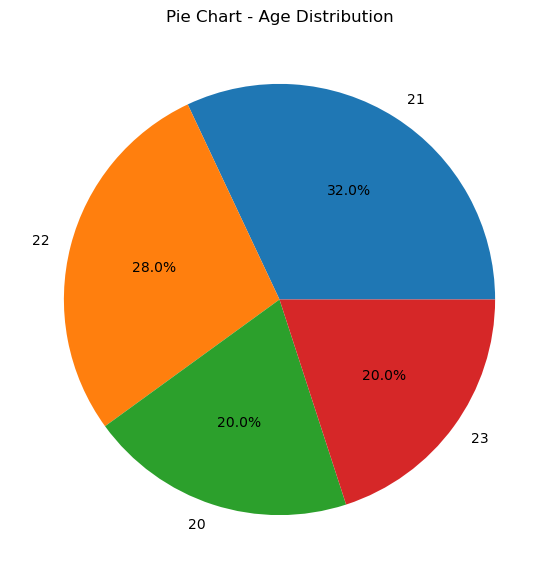

In [118]:
import matplotlib.pyplot as plt

counts = p["Age"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title("Pie Chart - Age Distribution")

plt.show()


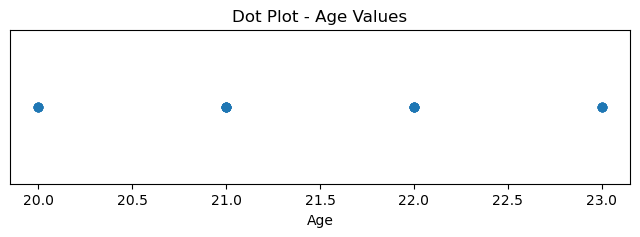

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,2))

plt.scatter(p["Age"], [0]*len(p["Age"]))

plt.title("Dot Plot - Age Values")
plt.xlabel("Age")
plt.yticks([])   # hide y-axis

plt.show()


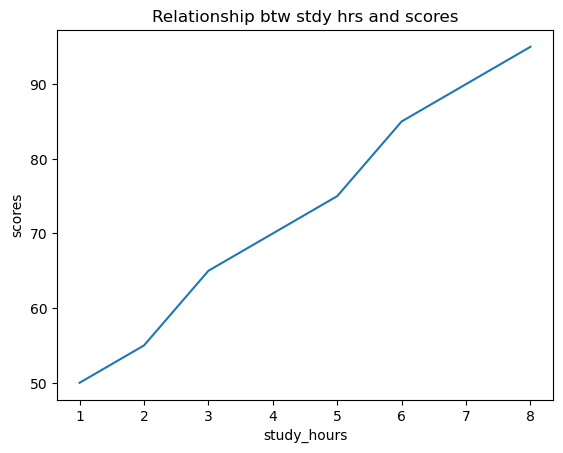

In [122]:

import matplotlib.pyplot as plt
study_hours = [1, 2, 3, 4, 5, 6, 7, 8]
scores = [50, 55, 65, 70, 75, 85, 90, 95]

plt.plot(study_hours, scores)

plt.title("Relationship btw stdy hrs and scores")
plt.xlabel("study_hours")
plt.ylabel("scores")
plt.show()


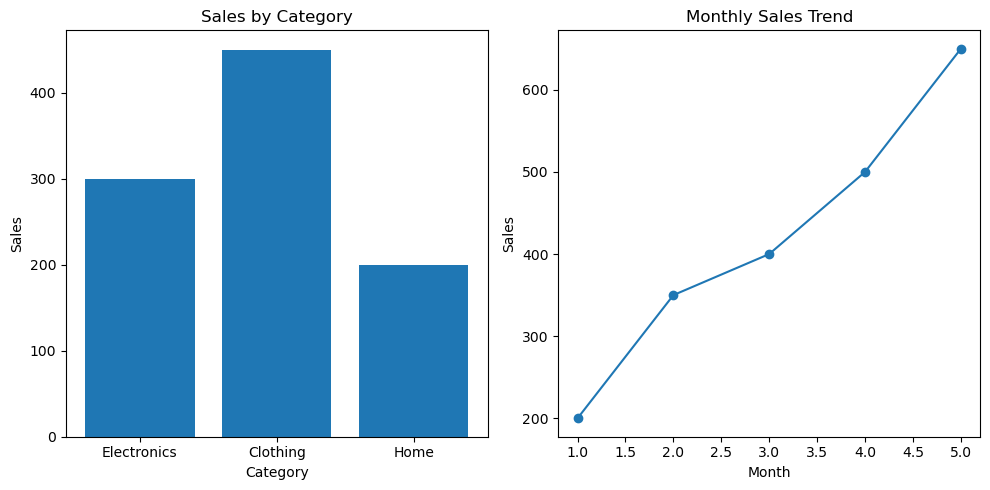

In [123]:
import matplotlib.pyplot as plt

categories = ['Electronics', 'Clothing', 'Home']
sales = [300, 450, 200]
months = [1, 2, 3, 4, 5]
monthly_sales = [200, 350, 400, 500, 650]

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.bar(categories, sales)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.subplot(1, 2, 2)
plt.plot(months, monthly_sales, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()

plt.show()
